#### Generating phase plots of autaptic neurons

We'll make the U-V phase plot of the autaptic neuron

autapse adds a time-varying function to the injected current, so a 3rd dimension may be needed


In [14]:

#imports for AQUA
import aqua
from aqua.AQUA_general import AQUA
from aqua.batchAQUA_general import batchAQUA
from aqua.plotting_functions import *


import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import entropy
from scipy.ndimage import gaussian_filter
from tqdm import tqdm

import seaborn as sns
sns.set_theme(style = "white")

In [15]:
# We'll start by implementing the RS neuron.
# Just show the phase plot for the neuron with no autapse

# simulation params
T = 500
dt = 0.01
N_iter = int(T/dt)

# RS neuron params
RS = {
    "name": "RS_intHD",
    "C": 100.0,
    "k": 0.7,
    "v_r": -60.0,
    "v_t": -40.0,
    "v_peak": 35.0,
    "a": 0.03,
    "b": -2.0,
    "c": -50.0,
    "d": 100.0,
    "e": 0.2,
    "f": 150.0,
    "tau": 2.0,
}


# injected current value
I = 0

# meshgrids for V and U
v = np.linspace(-100, 40, 100)
u = np.linspace(-30, 120, 100)
V, U = np.meshgrid(v, u)
W = np.zeros(V.shape)

N_neurons = len(v) * len(u)

params = [RS for _ in range(N_neurons)]

start_coords = np.vstack([V.ravel(), U.ravel(), W.ravel()]).T
t_start = np.zeros(N_neurons)

#initialise the batch
batch = batchAQUA(params)
batch.Initialise(start_coords, t_start)

# calculate dv, du
deriv = batch.neuron_model(batch.x, np.zeros(N_neurons), I*np.ones(N_neurons))

dv = deriv[:, 0].reshape(V.shape)
du = deriv[:, 1].reshape(U.shape)

speed = np.sqrt(dv**2 + du**2)


[[ 1. 16.  0.]]


100%|██████████| 49999/49999 [00:05<00:00, 8541.58it/s]


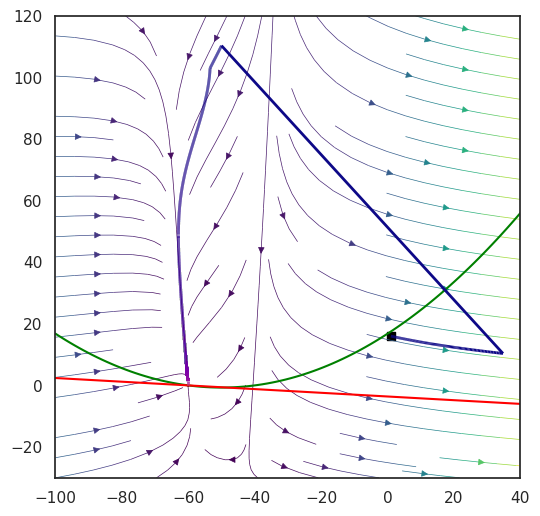

In [ ]:
def calculate_nullclines(v, u, w, I, p):

    v_null = (1/p["C"])*(p["k"]*(v - p["v_r"])*(v - p["v_t"]) + w + I)
    u_null = p["a"]*(p["b"]*(v - p["v_r"]))

    return v_null, u_null


# Now plot the flow field at the start
fig, ax = plt.subplots(figsize = (6,6))

ax.streamplot(
                V,
                U,
                dv,
                du,
                color=speed,
                cmap="viridis",
                density=0.8,
                linewidth=0.5,
                arrowsize=1.0,
            )


# plot the nullclines
w = W[0, :]
i = I * np.ones(len(w))
v_null, u_null = calculate_nullclines(v, u, w, i, RS)

ax.plot(v, v_null, c = 'green')
ax.plot(v, u_null, c = 'red')
ax.set_xlim(np.min(v), np.max(v))
ax.set_ylim(np.min(u), np.max(u))


# show a single trajectory
# simulation params
T = 500
dt = 0.01
N_iter = int(T/dt)
# injected current
N_points = 1
I_inj = I*np.ones((N_points, N_iter))

params = [RS for _ in range(N_points)]

neuron = batchAQUA(params)
x_start = np.zeros((N_points, 3))
x_start[:, 0] = np.random.randint(low = -80, high = 20, size = N_points)
x_start[:, 1] = np.random.randint(low = -20, high = 20, size = N_points)
print(x_start)
t_start = np.zeros(N_points)
neuron.Initialise(x_start, t_start)

X, T, spikes = neuron.update_batch(dt, N_iter, I_inj)

split = np.arange(0, int(N_iter))
for n in range(N_points):
    collection = plot_time_gradient(X[n, :], T, split)
    ax.add_collection(collection)
ax.scatter(x = X[:, 0, 0], y = X[:, 1, 0], color = 'black', marker = 's')